<a href="https://colab.research.google.com/github/ambroz72/German-Credit-Risks/blob/main/German_Credit_phase1_raw_data_to_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install ucimlrepo -q

In [9]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

In [10]:
 # Step 1: Fetch the raw dataset from UCI
# ---------------------------------------------------------
statlog_german_credit_data = fetch_ucirepo(id=144)

X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets

df = pd.concat([X, y], axis=1)


In [11]:

# Step 2: Rename columns to meaningful names
# ---------------------------------------------------------
column_names = [
    "checking_account_status", "duration_months", "credit_history",
    "purpose", "credit_amount", "savings_account", "employment_since",
    "installment_rate_pct", "personal_status_sex", "other_debtors",
    "present_residence_since", "property", "age", "other_installment_plans",
    "housing", "existing_credits_count", "job", "dependents_count",
    "telephone", "foreign_worker", "credit_risk"
]
df.columns = column_names

In [13]:
# Step 3: Decode the cryptic A11/A34/... codes into labels
# ---------------------------------------------------------
checking_account_map = {
    "A11": "< 0 DM", "A12": "0 to 200 DM",
    "A13": ">= 200 DM", "A14": "no checking account"
}
credit_history_map = {
    "A30": "no credits / all paid duly elsewhere",
    "A31": "all credits at this bank paid duly",
    "A32": "existing credits paid duly till now",
    "A33": "delay in paying off in the past",
    "A34": "critical account / other credits existing"
}
purpose_map = {
    "A40": "new car", "A41": "used car", "A42": "furniture/equipment",
    "A43": "radio/television", "A44": "domestic appliances",
    "A45": "repairs", "A46": "education", "A47": "vacation",
    "A48": "retraining", "A49": "business", "A410": "other"
}
savings_map = {
    "A61": "< 100 DM", "A62": "100 to 500 DM", "A63": "500 to 1000 DM",
    "A64": ">= 1000 DM", "A65": "unknown / no savings account"
}
employment_map = {
    "A71": "unemployed", "A72": "< 1 year", "A73": "1 to 4 years",
    "A74": "4 to 7 years", "A75": ">= 7 years"
}
personal_status_map = {
    "A91": "male: divorced/separated", "A92": "female: divorced/separated/married",
    "A93": "male: single", "A94": "male: married/widowed", "A95": "female: single"
}
other_debtors_map = {
    "A101": "none", "A102": "co-applicant", "A103": "guarantor"
}
property_map = {
    "A121": "real estate", "A122": "building society savings/life insurance",
    "A123": "car or other property", "A124": "unknown / no property"
}
other_installment_map = {
    "A141": "bank", "A142": "stores", "A143": "none"
}
housing_map = {
    "A151": "rent", "A152": "own", "A153": "for free"
}
job_map = {
    "A171": "unemployed/unskilled non-resident",
    "A172": "unskilled resident",
    "A173": "skilled employee/official",
    "A174": "management/self-employed/highly qualified"
}
telephone_map = {
    "A191": "none", "A192": "registered"
}
foreign_worker_map = {
    "A201": "yes", "A202": "no"
}
credit_risk_map = {1: "good", 2: "bad"}

df["checking_account_status"] = df["checking_account_status"].map(checking_account_map)
df["credit_history"] = df["credit_history"].map(credit_history_map)
df["purpose"] = df["purpose"].map(purpose_map)
df["savings_account"] = df["savings_account"].map(savings_map)
df["employment_since"] = df["employment_since"].map(employment_map)
df["personal_status_sex"] = df["personal_status_sex"].map(personal_status_map)
df["other_debtors"] = df["other_debtors"].map(other_debtors_map)
df["property"] = df["property"].map(property_map)
df["other_installment_plans"] = df["other_installment_plans"].map(other_installment_map)
df["housing"] = df["housing"].map(housing_map)
df["job"] = df["job"].map(job_map)
df["telephone"] = df["telephone"].map(telephone_map)
df["foreign_worker"] = df["foreign_worker"].map(foreign_worker_map)
df["credit_risk"] = df["credit_risk"].map(credit_risk_map)


In [14]:

# Step 4: Quick sanity checks
# ---------------------------------------------------------
print("Shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())
print("\nTarget distribution:\n", df["credit_risk"].value_counts())
df.head()


Shape: (1000, 21)

Missing values per column:
 checking_account_status    0
duration_months            0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment_since           0
installment_rate_pct       0
personal_status_sex        0
other_debtors              0
present_residence_since    0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits_count     0
job                        0
dependents_count           0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

Target distribution:
 credit_risk
good    700
bad     300
Name: count, dtype: int64


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits_count,job,dependents_count,telephone,foreign_worker,credit_risk
0,< 0 DM,6,critical account / other credits existing,radio/television,1169,unknown / no savings account,>= 7 years,4,male: single,none,...,real estate,67,none,own,2,skilled employee/official,1,registered,yes,good
1,0 to 200 DM,48,existing credits paid duly till now,radio/television,5951,< 100 DM,1 to 4 years,2,female: divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,none,yes,bad
2,no checking account,12,critical account / other credits existing,education,2096,< 100 DM,4 to 7 years,2,male: single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,< 0 DM,42,existing credits paid duly till now,furniture/equipment,7882,< 100 DM,4 to 7 years,2,male: single,guarantor,...,building society savings/life insurance,45,none,for free,1,skilled employee/official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,new car,4870,< 100 DM,1 to 4 years,3,male: single,none,...,unknown / no property,53,none,for free,2,skilled employee/official,2,none,yes,bad


Create your project folder in Drive

In [15]:
import os
project_path = '/content/drive/MyDrive/credit-risk-germany'
os.makedirs(f'{project_path}/data/raw', exist_ok=True)
os.makedirs(f'{project_path}/data/processed', exist_ok=True)
os.makedirs(f'{project_path}/notebooks', exist_ok=True)
os.makedirs(f'{project_path}/reports', exist_ok=True)
print("Project folder ready at:", project_path)

Project folder ready at: /content/drive/MyDrive/credit-risk-germany


Save leaned csv to deive

In [16]:
df.to_csv(f'{project_path}/data/raw/german_credit_clean.csv', index=False)
print("Saved to:", f'{project_path}/data/raw/german_credit_clean.csv')

Saved to: /content/drive/MyDrive/credit-risk-germany/data/raw/german_credit_clean.csv


In [17]:
check = pd.read_csv(f'{project_path}/data/raw/german_credit_clean.csv')
check.sample(5)

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits_count,job,dependents_count,telephone,foreign_worker,credit_risk
928,no checking account,30,existing credits paid duly till now,radio/television,1867,unknown / no savings account,>= 7 years,4,male: single,none,...,car or other property,58,none,own,1,skilled employee/official,1,registered,yes,good
206,no checking account,12,critical account / other credits existing,furniture/equipment,1935,< 100 DM,>= 7 years,4,male: single,none,...,real estate,43,none,own,3,skilled employee/official,1,registered,yes,good
182,< 0 DM,21,all credits at this bank paid duly,new car,1647,unknown / no savings account,1 to 4 years,4,male: single,none,...,building society savings/life insurance,40,none,own,2,unskilled resident,2,none,yes,bad
496,0 to 200 DM,36,existing credits paid duly till now,furniture/equipment,9034,100 to 500 DM,< 1 year,4,male: single,co-applicant,...,unknown / no property,29,none,rent,1,management/self-employed/highly qualified,1,registered,yes,bad
871,>= 200 DM,6,critical account / other credits existing,new car,1343,< 100 DM,>= 7 years,1,male: single,none,...,real estate,46,none,own,2,skilled employee/official,2,none,no,good


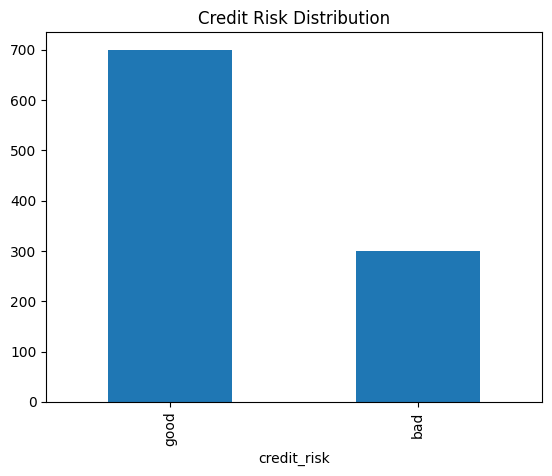

In [18]:
import matplotlib.pyplot as plt
df['credit_risk'].value_counts().plot(kind='bar', title='Credit Risk Distribution')
plt.show()